<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/10%EC%A3%BC%EC%B0%A8/pandas_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting started tutorials**
### **참고자료 : https://pandas.pydata.org/**

| No. | Title | Description |
|-----|-------|-------------|
||||
|----->|**pandas_01.ipynb**|--|
| 1 | What kind of data does pandas handle? (판다스는 어떤 종류의 데이터를 다루는가?) | Tabular data, time series, labeled data with axes, structured mixed-type data |
| 2 | How do I read and write tabular data? (표 형식 데이터를 어떻게 읽고 쓰는가?) | Use `pd.read_csv()`, `pd.read_excel()` to read; `df.to_csv()`, `df.to_excel()` to write |
| 3 | How do I select a subset of a DataFrame? (DataFrame에서 부분 선택은 어떻게 하는가?) | Use column selection, `df.loc[]`, `df.iloc[]`, and condition filtering |
||||
||||
|----->|**pandas_02.ipynb**|--|
| 4 | How do I create plots in pandas? (판다스에서 시각화를 어떻게 하는가?) | Use `df.plot()`, `df.hist()`, etc., built on `matplotlib` |
| 5 | How to create new columns derived from existing columns (기존 열로부터 새 열을 만드는 방법은?) | Perform operations like `df['new'] = df['a'] + df['b']` or use functions |
| 6 | How to calculate summary statistics (요약 통계를 계산하는 방법은?) | Use methods like `df.describe()`, `df.mean()`, `df.std()`, etc. |
| 7 | How to reshape the layout of tables (테이블 구조를 변경하는 방법은?) | Use `pivot()`, `melt()`, `stack()`, `unstack()`, or transpose with `df.T` |
||||
||||
|----->|**pandas_03.ipynb**|--|
| 8 | How to combine data from multiple tables (여러 테이블의 데이터를 결합하는 방법은?) | Use `pd.concat()`, `pd.merge()`, or `df.join()` by key/index |
| 9 | How to handle time series data with ease (시계열 데이터를 쉽게 다루는 방법은?) | Use `pd.to_datetime()`, `resample()`, `set_index()`, and time-based slicing |
| 10 | How to manipulate textual data (문자 데이터를 조작하는 방법은?) | Use `str` methods like `.lower()`, `.contains()`, `.replace()` with regex |


###**[강력 추천서: Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)**

#<font color='orange'> **8. How to combine data from multiple tables?**

##<font color='orange'> **Concatenating objects**

<img src='https://pandas.pydata.org/docs/_images/08_concat_row.svg'>


###**[Python DataScience Handbook github](https://github.com/jakevdp/PythonDataScienceHandbook)**
- **[03.07-Merge-and-Join.ipynb 참고](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/03.07-Merge-and-Join.ipynb)**

In [2]:
import pandas as pd
import numpy as np

class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args

    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)

    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

### One-to-One Joins
Perhaps the simplest type of merge is the one-to-one join, which is in many ways similar to the column-wise concatenation you saw in Combining Datasets: Concat & Append. As a concrete example, consider the following two DataFrame objects, which contain information on several employees in a company:

In [3]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lisa', 'Sue'],
                    'group': ['Accounting', 'Engineering',
                              'Engineering', 'HR']})
df2 = pd.DataFrame({'employee': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})
display('df1', 'df2')

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR
,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


In [4]:
df3 = pd.merge(df1, df2)

display('df1', 'df2', 'df3')

df1
  employee        group
0      Bob   Accounting
1     Jake  Engineering
2     Lisa  Engineering
3      Sue           HR

df2
  employee  hire_date
0     Lisa       2004
1      Bob       2008
2     Jake       2012
3      Sue       2014

df3
  employee        group  hire_date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014

### Many-to-One Joins
Many-to-one joins are joins in which one of the two key columns contains duplicate entries. For the many-to-one case, the resulting DataFrame will preserve those duplicate entries as appropriate. Consider the following example of a many-to-one join:

In [5]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                    'supervisor': ['Carly', 'Guido', 'Steve']})

display('df3', 'df4', 'pd.merge(df3, df4)')

df3
  employee        group  hire_date
0      Bob   Accounting       2008
1     Jake  Engineering       2012
2     Lisa  Engineering       2004
3      Sue           HR       2014

df4
         group supervisor
0   Accounting      Carly
1  Engineering      Guido
2           HR      Steve

pd.merge(df3, df4)
  employee        group  hire_date supervisor
0      Bob   Accounting       2008      Carly
1     Jake  Engineering       2012      Guido
2     Lisa  Engineering       2004      Guido
3      Sue           HR       2014      Steve

### Many-to-Many Joins
Many-to-many joins may be a bit confusing conceptually, but are nevertheless well defined. If the key column in both the left and right arrays contains duplicates, then the result is a many-to-many merge. This will be perhaps most clear with a concrete example. Consider the following, where we have a DataFrame showing one or more skills associated with a particular group. By performing a many-to-many join, we can recover the skills associated with any individual person:

In [6]:
df5 = pd.DataFrame({'group': ['Accounting', 'Accounting',
                              'Engineering', 'Engineering', 'HR', 'HR'],
                    'skills': ['math', 'spreadsheets', 'software', 'math',
                               'spreadsheets', 'organization']})

display('df1', 'df5', "pd.merge(df1, df5)")

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR
,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,software
3,Engineering,math
4,HR,spreadsheets


### **Obtain Data**

In [9]:
air_quality_no2 = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2_long.csv',
                              parse_dates=True)
air_quality_no2 = air_quality_no2[["date.utc", "location",
                                   "parameter", "value"]]
air_quality_no2.head()

,date.utc,location,parameter,value
0,2019-06-21 00:00:00+00:00,FR04014,no2,20.0
1,2019-06-20 23:00:00+00:00,FR04014,no2,21.8
2,2019-06-20 22:00:00+00:00,FR04014,no2,26.5
3,2019-06-20 21:00:00+00:00,FR04014,no2,24.9
4,2019-06-20 20:00:00+00:00,FR04014,no2,21.4


In [10]:
air_quality_pm25 = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_pm25_long.csv",
                                 parse_dates=True)

air_quality_pm25 = air_quality_pm25[["date.utc", "location",
                                       "parameter", "value"]]
air_quality_pm25.head()

,date.utc,location,parameter,value
0,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0
1,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5
2,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5
3,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0
4,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5


In [11]:
air_quality_no2.shape, air_quality_pm25.shape

((2068, 4), (1110, 4))

In [12]:
air_quality = pd.concat([air_quality_pm25, air_quality_no2], axis=0)
air_quality.shape

(3178, 4)

In [13]:
air_quality.head()

,date.utc,location,parameter,value
0,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0
1,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5
2,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5
3,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0
4,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5


In [14]:
# prompt: The air quality parameters metadata are stored in a data file air_quality_parameters.csv, downloaded using the py-openaq package.

import pandas as pd
air_quality_parameters = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_parameters.csv')
air_quality_parameters.head()

,id,description,name
0,bc,Black Carbon,BC
1,co,Carbon Monoxide,CO
2,no2,Nitrogen Dioxide,NO2
3,o3,Ozone,O3
4,pm10,Particulate matter less than 10 micrometers in...,PM10


In [15]:
# prompt: 데이터프레임의 각 털럼의 고유값, 결측치, 대표값 5개를 데이터프레임으로 생성하는 함수를 만들어라

import pandas as pd
def analyze_dataframe(df):
  """
  데이터프레임의 각 컬럼의 고유값, 결측치, 대표값 5개를 포함하는 데이터프레임을 생성합니다.

  Args:
    df: 분석할 pandas DataFrame.

  Returns:
    각 컬럼의 분석 결과를 포함하는 pandas DataFrame.
  """
  analysis_results = []
  for col in df.columns:
    unique_values = df[col].nunique()
    missing_values = df[col].isnull().sum()
    # 컬럼 타입에 따라 대표값 5개를 추출
    if df[col].dtype in ['int64', 'float64']:
      top_5_values = df[col].value_counts().head(5).index.tolist()
    else:
      top_5_values = df[col].value_counts().head(5).index.tolist()


    analysis_results.append({
        '컬럼명': col,
        '고유값 개수': unique_values,
        '결측치 개수': missing_values,
        '대표값 5개': top_5_values
    })

  return pd.DataFrame(analysis_results)

# 예시 사용: air_quality 데이터프레임 분석
analyze_dataframe(air_quality)

,컬럼명,고유값 개수,결측치 개수,대표값 5개
0,date.utc,1041,0,"[2019-05-18 18:00:00+00:00, 2019-05-18 19:00:0..."
1,location,3,0,"[London Westminster, FR04014, BETR801]"
2,parameter,2,0,"[no2, pm25]"
3,value,464,0,"[7.0, 8.0, 6.0, 9.0, 10.0]"


In [16]:
analyze_dataframe(air_quality_parameters)

,컬럼명,고유값 개수,결측치 개수,대표값 5개
0,id,7,0,"[bc, co, no2, o3, pm10]"
1,description,7,0,"[Black Carbon, Carbon Monoxide, Nitrogen Dioxi..."
2,name,7,0,"[BC, CO, NO2, O3, PM10]"


In [17]:
air_quality = pd.merge(air_quality, air_quality_parameters,
                       how='left', left_on='parameter', right_on='id')

air_quality

,date.utc,location,parameter,value,id,description,name
0,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,pm25,Particulate matter less than 2.5 micrometers i...,PM2.5
1,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,pm25,Particulate matter less than 2.5 micrometers i...,PM2.5
2,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,pm25,Particulate matter less than 2.5 micrometers i...,PM2.5
3,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,pm25,Particulate matter less than 2.5 micrometers i...,PM2.5
4,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,pm25,Particulate matter less than 2.5 micrometers i...,PM2.5
...,...,...,...,...,...,...,...
3173,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,no2,Nitrogen Dioxide,NO2
3174,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,no2,Nitrogen Dioxide,NO2
3175,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,no2,Nitrogen Dioxide,NO2
3176,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,no2,Nitrogen Dioxide,NO2


#<font color='orange'> **9. How to handle time series data with ease?**

In [18]:
# prompt: https://github.com/pandas-dev/pandas/blob/main/doc/data/air_quality_no2_long.csv 를 air_quality 데이터프레임으로 읽어라

air_quality = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/air_quality_no2_long.csv')
air_quality = air_quality.rename(columns={"date.utc": "datetime"})

air_quality.head()

,city,country,datetime,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


In [19]:
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       2068 non-null   object 
 1   country    2068 non-null   object 
 2   datetime   2068 non-null   object 
 3   location   2068 non-null   object 
 4   parameter  2068 non-null   object 
 5   value      2068 non-null   float64
 6   unit       2068 non-null   object 
dtypes: float64(1), object(6)
memory usage: 113.2+ KB


In [20]:
air_quality["datetime"] = pd.to_datetime(air_quality["datetime"])
air_quality["datetime"]

,datetime
0,2019-06-21 00:00:00+00:00
1,2019-06-20 23:00:00+00:00
2,2019-06-20 22:00:00+00:00
3,2019-06-20 21:00:00+00:00
4,2019-06-20 20:00:00+00:00
...,...
2063,2019-05-07 06:00:00+00:00
2064,2019-05-07 04:00:00+00:00
2065,2019-05-07 03:00:00+00:00
2066,2019-05-07 02:00:00+00:00


In [21]:
air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   city       2068 non-null   object             
 1   country    2068 non-null   object             
 2   datetime   2068 non-null   datetime64[ns, UTC]
 3   location   2068 non-null   object             
 4   parameter  2068 non-null   object             
 5   value      2068 non-null   float64            
 6   unit       2068 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(5)
memory usage: 113.2+ KB


In [22]:
air_quality["datetime"].min(), air_quality["datetime"].max()

(Timestamp('2019-05-07 01:00:00+0000', tz='UTC'),
 Timestamp('2019-06-21 00:00:00+0000', tz='UTC'))

In [23]:
air_quality["datetime"].max() - air_quality["datetime"].min()

Timedelta('44 days 23:00:00')

In [ ]:
air_quality["month"] = air_quality["datetime"].dt.month
air_quality["day_of_week"] = air_quality["datetime"].dt.dayofweek
air_quality

,city,country,datetime,location,parameter,value,unit,month,day_of_week
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6,4
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6,3
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6,3
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6,3
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6,3
...,...,...,...,...,...,...,...,...,...
2063,London,GB,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,µg/m³,5,1
2064,London,GB,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,µg/m³,5,1
2065,London,GB,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,µg/m³,5,1
2066,London,GB,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,µg/m³,5,1


In [ ]:
air_quality.groupby(['day_of_week', "city"])["value"].mean()

day_of_week  city     
0            Antwerpen    27.875000
             London       23.969697
             Paris        24.856250
1            Antwerpen    22.214286
             London       24.885714
             Paris        30.999359
2            Antwerpen    21.125000
             London       23.460432
             Paris        29.165753
3            Antwerpen    27.500000
             London       24.780142
             Paris        28.600690
4            Antwerpen    28.400000
             London       26.446809
             Paris        31.617986
5            Antwerpen    33.500000
             London       24.977612
             Paris        25.266154
6            Antwerpen    21.896552
             London       24.859155
             Paris        23.274306
Name: value, dtype: float64

In [24]:
# prompt: day_of_week 을 요일로 mapping하라. 영어로

air_quality["day_of_week_name"] = air_quality["datetime"].dt.day_name()
air_quality.head()

,city,country,datetime,location,parameter,value,unit,day_of_week_name
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,Friday
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,Thursday
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,Thursday
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,Thursday
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,Thursday


In [25]:
air_quality.groupby(["day_of_week_name", "location"])["value"].mean()

day_of_week_name  location          
Friday            BETR801               28.400000
                  FR04014               31.617986
                  London Westminster    26.446809
Monday            BETR801               27.875000
                  FR04014               24.856250
                  London Westminster    23.969697
Saturday          BETR801               33.500000
                  FR04014               25.266154
                  London Westminster    24.977612
Sunday            BETR801               21.896552
                  FR04014               23.274306
                  London Westminster    24.859155
Thursday          BETR801               27.500000
                  FR04014               28.600690
                  London Westminster    24.780142
Tuesday           BETR801               22.214286
                  FR04014               30.999359
                  London Westminster    24.885714
Wednesday         BETR801               21.125000
                  FR04014               29.165753
                  London Westminster    23.460432
Name: value, dtype: float64

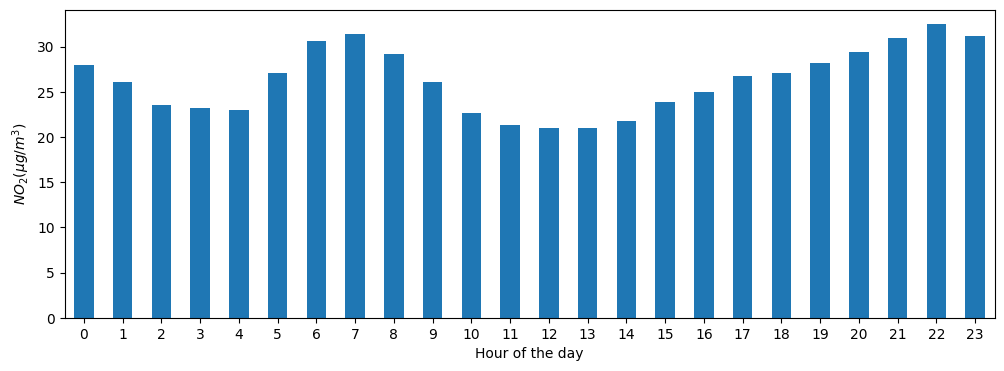

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(12, 4))

air_quality.groupby(air_quality["datetime"].dt.hour)["value"].mean().plot(kind='bar', rot=0, ax=axs)
plt.xlabel("Hour of the day");  # custom x label using Matplotlib
plt.ylabel("$NO_2 (µg/m^3)$");

##<font color='orange'> **Datetime as index**

In [28]:
no_2 = air_quality.pivot(index="datetime", columns="city", values="value")
no_2.head()

city,Antwerpen,London,Paris
datetime,,,
2019-05-07 01:00:00+00:00,50.5,23.0,25.0
2019-05-07 02:00:00+00:00,45.0,19.0,27.7
2019-05-07 03:00:00+00:00,NaN,19.0,50.4
2019-05-07 04:00:00+00:00,NaN,16.0,61.9
2019-05-07 05:00:00+00:00,NaN,NaN,72.4


In [29]:
no_2.index.year, no_2.index.weekday

(Index([2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019,
        ...
        2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019],
       dtype='int32', name='datetime', length=1033),
 Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        ...
        3, 3, 3, 3, 3, 3, 3, 3, 3, 4],
       dtype='int32', name='datetime', length=1033))

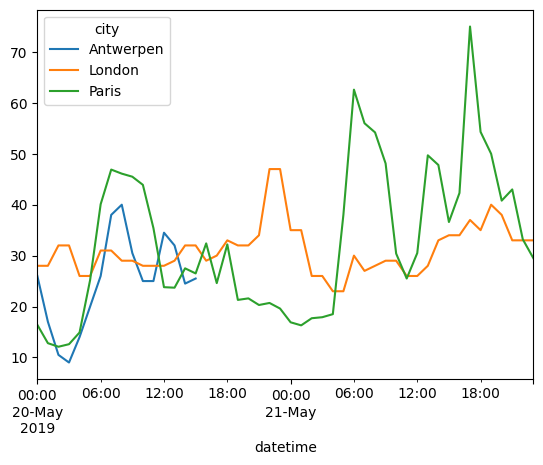

In [30]:
no_2["2019-05-20":"2019-05-21"].plot();

##<font color='orange'> **Resample a time series to another frequency**

In [31]:
monthly_max = no_2.resample("ME").max()
monthly_max

city,Antwerpen,London,Paris
datetime,,,
2019-05-31 00:00:00+00:00,74.5,97.0,97.0
2019-06-30 00:00:00+00:00,52.5,52.0,84.7


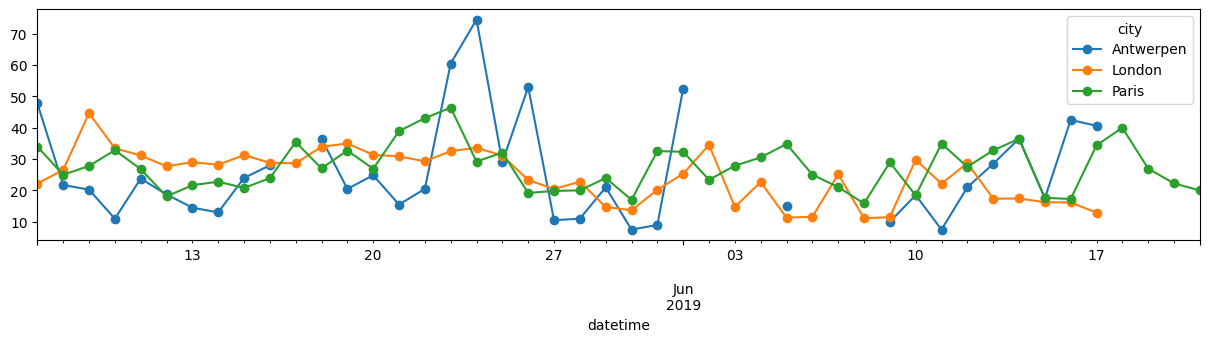

In [32]:
no_2.resample("D").mean().plot(style="-o", figsize=(15, 3));

#<font color='orange'> **10. How to manipulate textual data?**

In [33]:
# prompt: https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv  를 데이터프레임 titanic으로 일기

titanic = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
titanic["Name"]

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss Margaret Edith"
888,"Johnston, Miss Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [35]:
text = "Braund, Mr. Owen Harris"
text.lower()

'braund, mr. owen harris'

In [36]:
text.split(",")

['Braund', ' Mr. Owen Harris']

In [37]:
text.split(",")[0]

'Braund'

In [38]:
titanic["Name"].str.lower()

,Name
0,"braund, mr. owen harris"
1,"cumings, mrs. john bradley (florence briggs th..."
2,"heikkinen, miss laina"
3,"futrelle, mrs. jacques heath (lily may peel)"
4,"allen, mr. william henry"
...,...
886,"montvila, rev. juozas"
887,"graham, miss margaret edith"
888,"johnston, miss catherine helen ""carrie"""
889,"behr, mr. karl howell"


In [39]:
titanic["Name"].str.split(",")

,Name
0,"[Braund, Mr. Owen Harris]"
1,"[Cumings, Mrs. John Bradley (Florence Briggs ..."
2,"[Heikkinen, Miss Laina]"
3,"[Futrelle, Mrs. Jacques Heath (Lily May Peel)]"
4,"[Allen, Mr. William Henry]"
...,...
886,"[Montvila, Rev. Juozas]"
887,"[Graham, Miss Margaret Edith]"
888,"[Johnston, Miss Catherine Helen ""Carrie""]"
889,"[Behr, Mr. Karl Howell]"


In [40]:
titanic["Surname"] = titanic["Name"].str.split(",").str.get(0)
titanic["Surname"]

,Surname
0,Braund
1,Cumings
2,Heikkinen
3,Futrelle
4,Allen
...,...
886,Montvila
887,Graham
888,Johnston
889,Behr


In [41]:
titanic["Name"].str.contains("Countess")

,Name
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [42]:
titanic[titanic["Name"].str.contains("Countess")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,B77,S,Rothes


In [43]:
titanic["Name"].str.len()

,Name
0,23
1,51
2,21
3,44
4,24
...,...
886,21
887,27
888,39
889,21


In [44]:
titanic["Name"].str.len().idxmax()

307

In [45]:
titanic.loc[titanic["Name"].str.len().idxmax(), "Name"]

'Penasco y Castellana, Mrs. Victor de Satode (Maria Josefa Perez de Soto y Vallejo)'

In [46]:
titanic["Sex_short"] = titanic["Sex"].replace({"male": "M", "female": "F"})
titanic["Sex_short"]

,Sex_short
0,M
1,F
2,F
3,F
4,M
...,...
886,M
887,F
888,F
889,M


In [47]:
titanic["Sex_short"] = titanic["Sex"].str.replace("female", "F")
titanic["Sex_short"] = titanic["Sex_short"].str.replace("male", "M")

In [48]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Sex_short
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,F
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,F
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,F
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Montvila,M
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,F
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,F
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,M
